https://mp.weixin.qq.com/s/TSU6j1zsTkc7-kSS86U_MQ

# 通透！十大数据清洗方法 ！！

数据清洗是确保数据质量的关键步骤，能够消除噪声和错误，从而提高分析结果的准确性。良好的数据清洗方法能够增强模型的性能，减少过拟合和欠拟合的风险。通过系统化的数据清洗，可以节省后续分析和建模的时间，提高整体工作效率。

### 1. 缺失值处理
原理
缺失值处理是指在数据集中存在空值或缺失数据的情况下，通过合适的策略填补或处理这些缺失值，以减少对后续分析和模型训练的影响。常见的缺失值处理方法包括删除缺失值、均值填补、中位数填补、众数填补和插值法。

优缺点  
优点：  
可保持数据集的大小，减少数据丢失。  
使用简单的统计方法进行填补，便于实现。

缺点：  
可能引入偏差，尤其是当缺失值不是随机缺失时。  
对数据分布的影响可能导致模型性能下降。

适用场景  
数据集较小，且缺失值较少。  
缺失值的缺失机制已知且为随机缺失。

C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_12268\2720516449.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_12268\2720516449.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

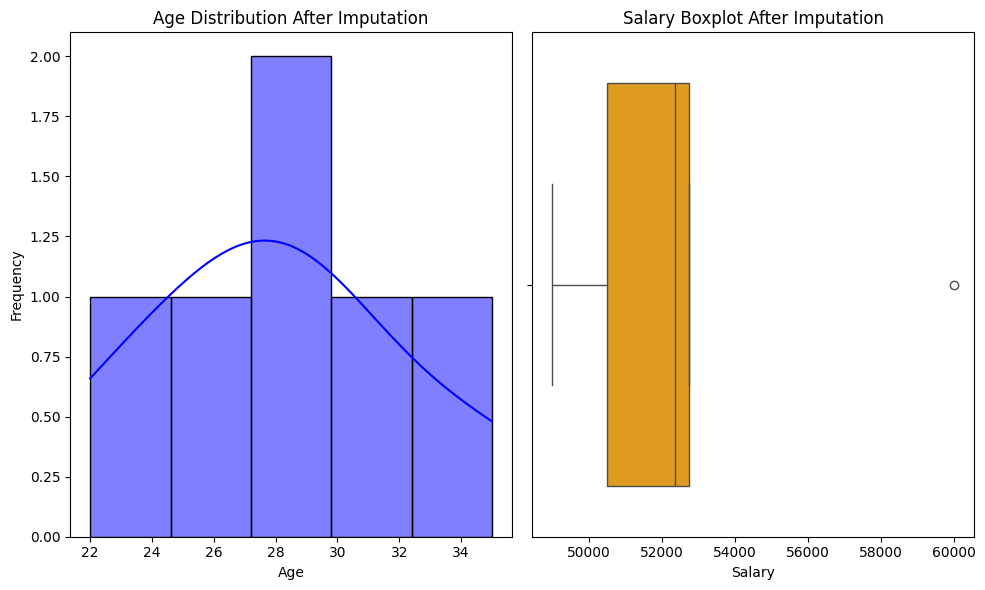

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建一个示例数据集
data = {
    'Age': [25, np.nan, 30, 22, np.nan, 35],
    'Salary': [50000, 60000, np.nan, 52000, 49000, np.nan]
}
df = pd.DataFrame(data)

# 缺失值处理：使用均值填补
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Salary'].fillna(df['Salary'].mean(), inplace=True)

# 数据分析：绘制直方图和箱线图
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=5, color='blue', kde=True)
plt.title('Age Distribution After Imputation')
plt.xlabel('Age')
plt.ylabel('Frequency')

# 绘制箱线图
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Salary'], color='orange')
plt.title('Salary Boxplot After Imputation')
plt.xlabel('Salary')

plt.tight_layout()
plt.show()

直方图: 展示填补后年龄的分布，帮助判断填补方法是否合理。理想情况下，数据应呈现出自然的分布形态。  
箱线图: 检查填补后的薪水数据分布及异常值，提供关于薪水变异的信息，理想情况下，箱体应该集中且无显著的离群点。


### 2. 异常值处理

原理  
异常值处理是指识别并处理那些与其他数据点显著不同的观测值。异常值可能是数据录入错误、测量错误或实际存在的极端现象。常见的处理方法包括 z-score、IQR（四分位距）法和基于模型的方法（如孤立森林）。

优缺点  
优点：  
有效地识别并处理潜在的噪声数据。  
Z-score 和 IQR 方法简单易懂，且不需要假设数据分布。

缺点：  
对于多维数据，单一维度的异常值检测可能会遗漏整体的异常。  
对于具有大量异常值的数据，可能会误判。

适用场景  
需要清理数据以提高模型性能。  
数据集存在明显的极端值时。

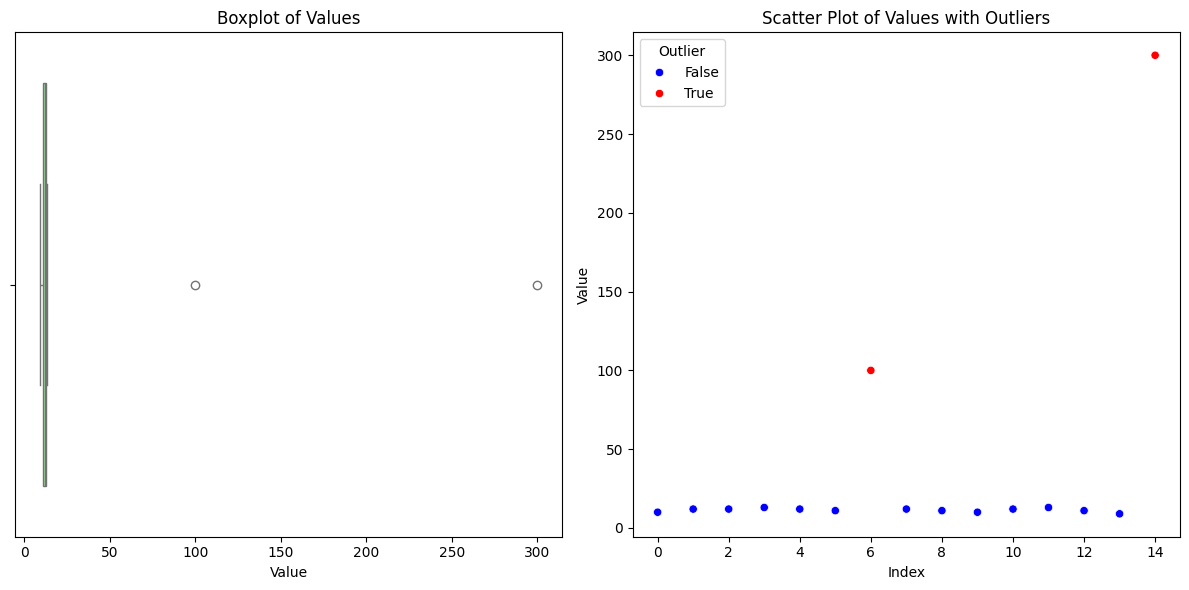

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 生成一个包含异常值的示例数据集
data = {
    'Value': [10, 12, 12, 13, 12, 11, 100, 12, 11, 10, 12, 13, 11, 9, 300]
}
df = pd.DataFrame(data)

# 计算IQR
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1

# 检测异常值
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Outlier'] = ((df['Value'] < lower_bound) | (df['Value'] > upper_bound))

# 数据分析：绘制箱线图和散点图
plt.figure(figsize=(12, 6))

# 绘制箱线图
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Value'], color='lightgreen')
plt.title('Boxplot of Values')
plt.xlabel('Value')

# 绘制散点图
plt.subplot(1, 2, 2)
sns.scatterplot(x=df.index, y='Value', hue='Outlier', data=df, palette={True: 'red', False: 'blue'})
plt.title('Scatter Plot of Values with Outliers')
plt.xlabel('Index')
plt.ylabel('Value')

plt.tight_layout()
plt.show()

箱线图: 展示数据的分布和异常值的情况，箱体外的点即为异常值，帮助快速识别数据中的极端点。  
散点图: 通过不同颜色标识出异常值和正常值，提供了更直观的异常值分布情况，便于观察其在数据集中的位置。

### 3. 重复数据移除

原理  
重复数据移除是通过识别数据集中相同的记录，避免分析中出现信息冗余，确保数据集的唯一性。重复数据通常通过查找完全相同的行或部分相同的特征来检测。

优缺点  
优点：  
消除冗余，提高数据集的质量。  
降低内存使用和计算开销。  

缺点：  
在某些情况下，重复数据可能有其存在的价值（如交易记录）。  
删除操作需谨慎，避免误删除有用的信息。  

适用场景  
数据集在数据收集过程中容易产生重复记录。  
数据预处理阶段需要清理以提高数据质量。

C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_12268\3875080447.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Name', data=df, palette='viridis')


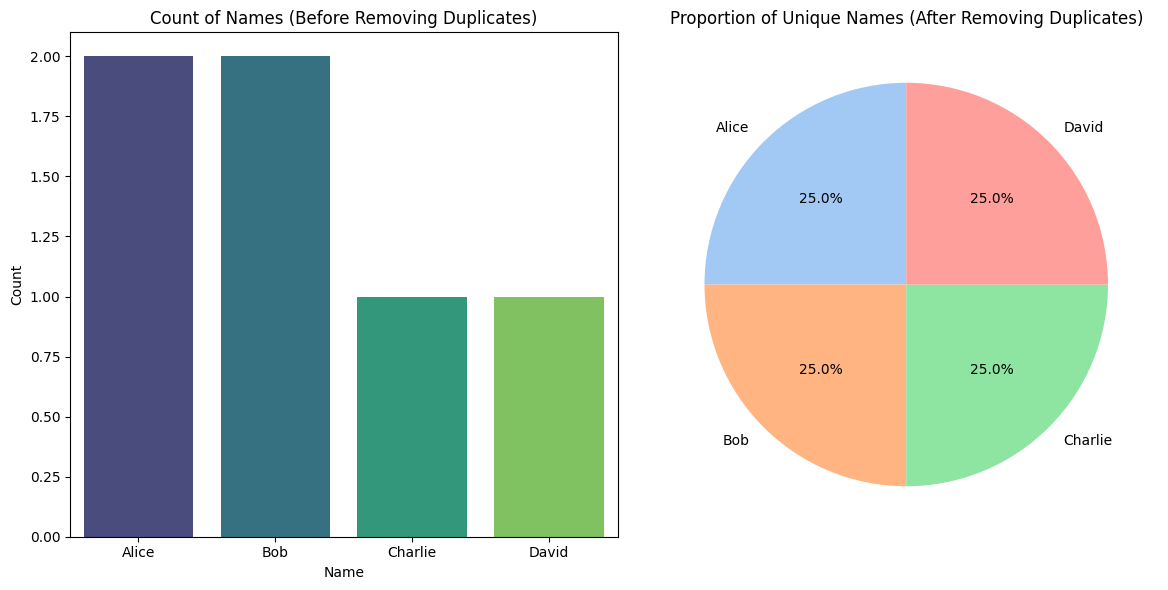

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 创建一个包含重复数据的示例数据集
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Alice', 'David', 'Bob'],
    'Age': [25, 30, 35, 25, 40, 30],
    'Salary': [50000, 60000, 70000, 50000, 80000, 60000]
}
df = pd.DataFrame(data)

# 移除重复数据
df_unique = df.drop_duplicates()

# 数据分析：绘制条形图和饼图
plt.figure(figsize=(12, 6))

# 绘制条形图
plt.subplot(1, 2, 1)
sns.countplot(x='Name', data=df, palette='viridis')
plt.title('Count of Names (Before Removing Duplicates)')
plt.xlabel('Name')
plt.ylabel('Count')

# 绘制饼图
plt.subplot(1, 2, 2)
df_unique['Name'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title('Proportion of Unique Names (After Removing Duplicates)')
plt.ylabel('')

plt.tight_layout()
plt.show()

条形图: 显示重复数据前每个名字的出现频率，便于观察哪些数据重复。  
饼图: 展示去重后每个唯一名字的比例，帮助判断数据的分布及集中情况。  

### 4. 数据一致性处理

原理

数据一致性处理是指确保数据在不同记录之间保持一致性，特别是在涉及多个数据源时。通过标准化字段格式、验证数据范围和逻辑关系来处理。

优缺点

优点：  
提高数据的可靠性和准确性。  
降低数据处理过程中的错误。  

缺点：  
一致性检查需要较多的时间和计算资源。  
可能会导致数据丢失（在标准化时）。  

适用场景  
合并多个数据源时，需要确保数据的统一性。  
进行数据分析时，需要确保数据的准确性。

<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_12268\1987502530.py:15: SyntaxWarning: invalid escape sequence '\$'
  df['Salary'] = df['Salary'].replace({'\$': '', ' ': ''}, regex=True).astype(float)
C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_12268\1987502530.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['ID'], y=df['Salary'], palette='rocket')


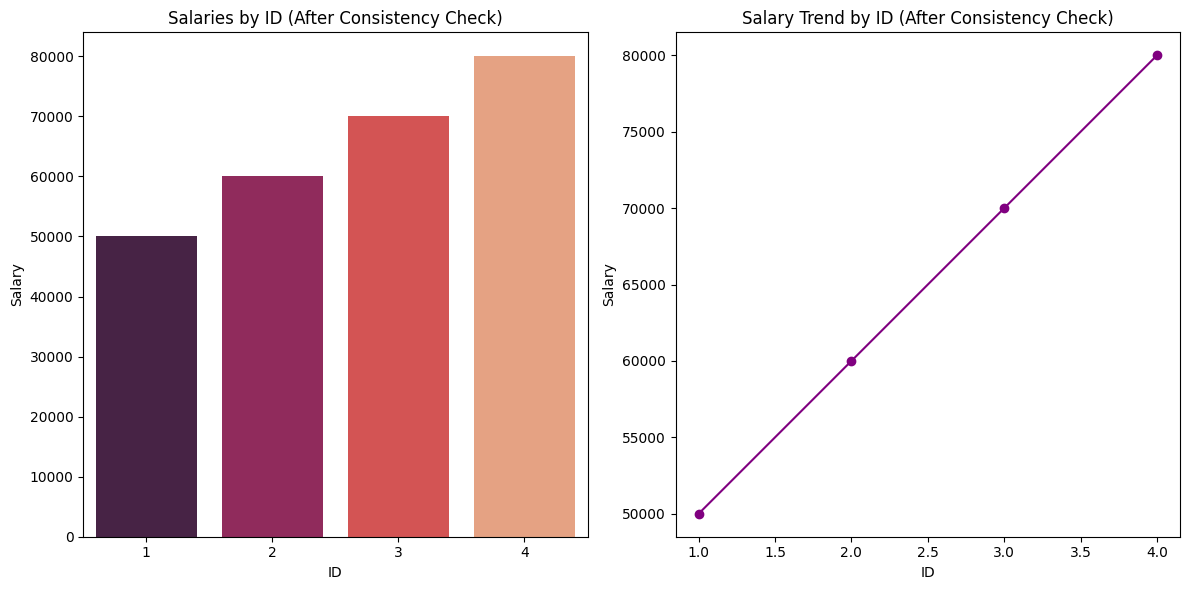

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 创建一个示例数据集
data = {
    'ID': [1, 2, 3, 4],
    'Date': ['2024-01-01', '01/02/2024', '2024-03-01', 'March 4, 2024'],
    'Salary': [50000, '60000$', '70000', 80000.0]
}
df = pd.DataFrame(data)

# 数据一致性处理：统一日期格式和薪资格式
df['Date'] = pd.to_datetime(df['Date'], errors='coerce').dt.strftime('%Y-%m-%d')
df['Salary'] = df['Salary'].replace({'\$': '', ' ': ''}, regex=True).astype(float)

# 数据分析：绘制条形图和折线图
plt.figure(figsize=(12, 6))

# 绘制条形图
plt.subplot(1, 2, 1)
sns.barplot(x=df['ID'], y=df['Salary'], palette='rocket')
plt.title('Salaries by ID (After Consistency Check)')
plt.xlabel('ID')
plt.ylabel('Salary')

# 绘制折线图
plt.subplot(1, 2, 2)
plt.plot(df['ID'], df['Salary'], marker='o', linestyle='-', color='purple')
plt.title('Salary Trend by ID (After Consistency Check)')
plt.xlabel('ID')
plt.ylabel('Salary')

plt.tight_layout()
plt.show()

条形图: 显示一致性处理后每个 ID 对应的薪资，帮助观察数据清洗后的结果。  
折线图: 展示薪资随 ID 的变化趋势，提供了薪资变化的清晰视图。

### 5. 数据归一化/标准化

原理  
数据归一化和标准化是通过将数据缩放到特定范围（如[0, 1]）或调整为均值为0、标准差为1来处理不同量纲和范围的特征，以提高模型的训练效果。

优缺点

优点：  
消除特征量纲影响，提高模型的收敛速度。  
适用于大多数机器学习算法，尤其是基于距离的算法。  

缺点：  
对于有异常值的数据，归一化可能会导致极端值对结果的影响增大。  
需要对每个特征单独处理，计算成本较高。  

适用场景  
特征值范围差异较大时。  
使用需要计算距离的算法（如 KNN、SVM）时。

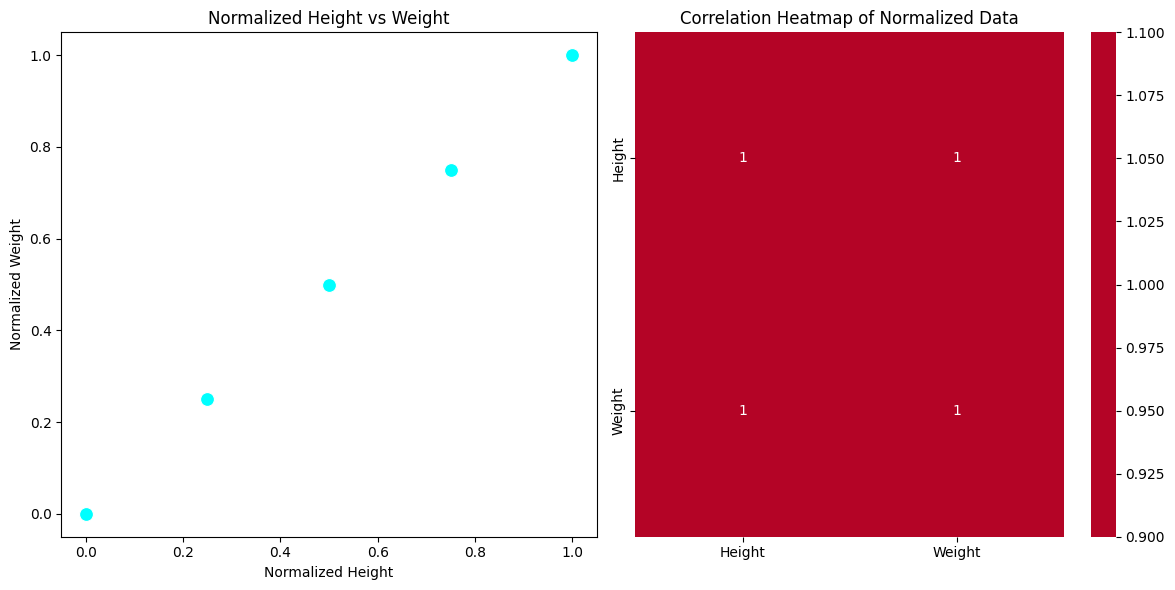

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 创建一个示例数据集
data = {
    'Height': [150, 160, 170, 180, 190],
    'Weight': [50, 60, 70, 80, 90]
}
df = pd.DataFrame(data)

# 数据归一化
df_normalized = (df - df.min()) / (df.max() - df.min())

# 数据分析：绘制散点图和热力图
plt.figure(figsize=(12, 6))

# 绘制散点图
plt.subplot(1, 2, 1)
sns.scatterplot(x=df_normalized['Height'], y=df_normalized['Weight'], color='cyan', s=100)
plt.title('Normalized Height vs Weight')
plt.xlabel('Normalized Height')
plt.ylabel('Normalized Weight')

# 绘制热力图
plt.subplot(1, 2, 2)
sns.heatmap(df_normalized.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Normalized Data')

plt.tight_layout()
plt.show()


散点图: 显示归一化后身高与体重的关系，便于观察特征之间的相关性。  
热力图: 展示归一化后特征间的相关性，帮助识别潜在的多重共线性问题。

### 6. 数据离散化  
原理  
数据离散化是将连续特征转换为离散特征的过程，以便在分类问题中提高模型的效果。常用方法包括分箱（Bin）和聚类。

优缺点  
优点：  
转换后的离散特征更易于解释和理解。  
可以提高某些算法（如决策树）的效果。  

缺点：  
可能导致信息损失，特别是连续性数据中的细节。  
选择分箱数和方法需要谨慎，影响模型性能。  

适用场景  
在分类问题中使用，需要将连续特征转换为类别特征。  
数据分析时需要对数据进行分组处理。  

C:\Users\wangx.MARVIN-HOME\AppData\Local\Temp\ipykernel_12268\1333989824.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Grade', data=df, palette='pastel')


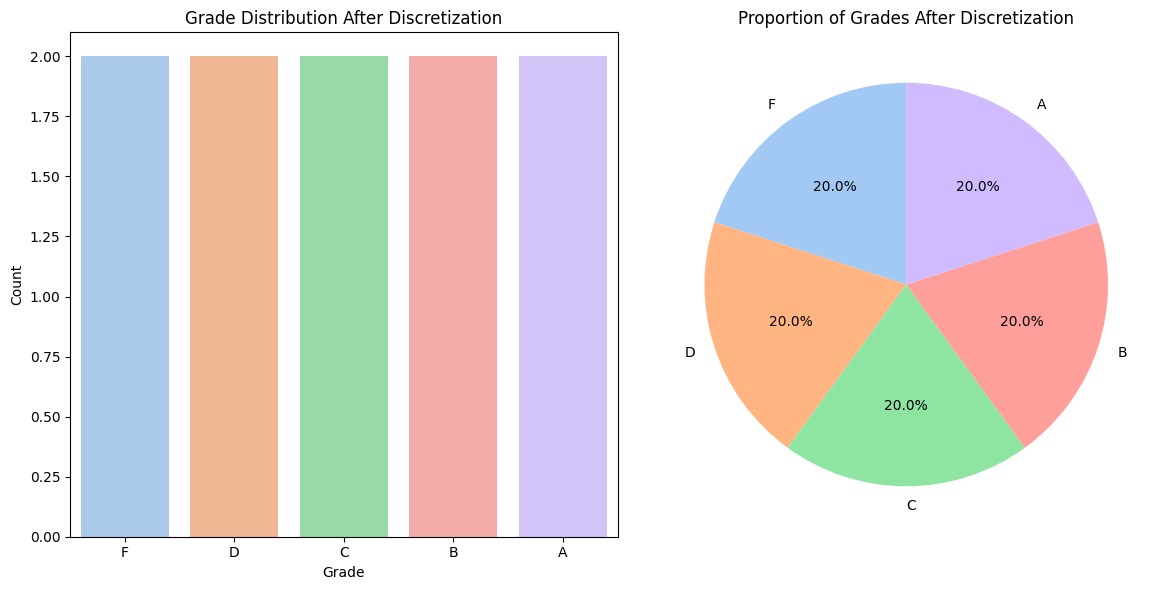

In [6]:
# 创建一个示例数据集
data = {
    'Score': [58, 73, 80, 90, 55, 88, 66, 74, 99, 61]
}
df = pd.DataFrame(data)

# 数据离散化：等宽分箱
bins = [0, 60, 70, 80, 90, 100]
labels = ['F', 'D', 'C', 'B', 'A']
df['Grade'] = pd.cut(df['Score'], bins=bins, labels=labels, right=False)

# 数据分析：绘制条形图和饼图
plt.figure(figsize=(12, 6))

# 绘制条形图
plt.subplot(1, 2, 1)
sns.countplot(x='Grade', data=df, palette='pastel')
plt.title('Grade Distribution After Discretization')
plt.xlabel('Grade')
plt.ylabel('Count')

# 绘制饼图
plt.subplot(1, 2, 2)
df['Grade'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title('Proportion of Grades After Discretization')
plt.ylabel('')

plt.tight_layout()
plt.show()

条形图: 显示不同等级的分布情况，便于观察离散化效果。  
饼图: 展示等级的比例分布，提供各等级的相对权重。

### ~未完待续~